# Kernel methods (SVM): Adult census income dataset

**ML-MDS 2026 - Elisa Muller and Berta Torrents**

## 0. Introduction

This notebook trains and evaluates Support Vector Machine classifiers on the Adult census income dataset. All models are evaluated under the same cross-validation protocol on the training partition produced by the preprocessing notebook, and the test partition is held out until the final evaluation.

SVMs approach classification differently from both the generative models and the linear models in this project. Rather than modelling class distributions or fitting a global linear boundary, an SVM finds the hyperplane that maximizes the margin between the two classes, concentrating the solution on the hardest examples near the boundary -- the support vectors. This makes the choice of kernel a core modelling decision: it determines what class of decision boundaries the model can represent, from flat hyperplanes to locally adaptive non-linear surfaces.

Three kernel families are covered: the linear kernel, which produces a hyperplane in the original feature space; the RBF kernel, which produces a locally smooth boundary controlled by a bandwidth parameter; and the polynomial kernel, which captures explicit feature interactions up to a specified degree.

## 1. Setup and data loading

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import RFECV, SelectFromModel, VarianceThreshold
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
)
from sklearn.svm import SVC, LinearSVC
from sklearn.utils import resample
from time import time

SEED = 42
np.random.seed(SEED)

PLOT_COLORS = {
    "neutral":       "#FA8FB1",
    "neutral_light": "#7DB7FF",
    "income_low":    "#2F80ED",
    "income_high":   "#FF8A00",
    "before":        "#7B8794",
    "after":         "#00B894",
    "outlier":       "#E63946",
    "reference":     "#4A5568",
}
TARGET_PALETTE = {0: PLOT_COLORS['income_low'], 1: PLOT_COLORS['income_high']}
MODEL_PALETTE = {
    "Baseline": "#8C8C8C",
    "Linear":   "#2F80ED",
    "RBF":      "#FF8A00",
    "Poly":     "#9B51E0",
}

sns.set_theme(
    style='whitegrid',
    palette=list(PLOT_COLORS.values()),
    rc={
        'axes.spines.right': False,
        'axes.spines.top':   False,
        'axes.edgecolor':    '#D7DEE8',
        'axes.linewidth':    0.8,
        'grid.color':        '#E8EDF3',
        'grid.linewidth':    0.7,
        'legend.frameon':    False,
    },
)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['figure.figsize']   = (10, 5)
plt.rcParams['axes.titleweight'] = 'semibold'
plt.rcParams['axes.titlepad']    = 10


def polish_axes(ax, grid_axis='y'):
    ax.grid(False)
    ax.grid(True, axis=grid_axis, alpha=0.55)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    return ax


warnings.filterwarnings('ignore')

In [2]:
X_train = pd.read_csv('adult_X_train.csv', index_col=0)
X_test  = pd.read_csv('adult_X_test.csv',  index_col=0)
y_train = pd.read_csv('adult_y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv('adult_y_test.csv',  index_col=0).squeeze()

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Class balance (train): {y_train.mean():.2%} positive (>50K)')

X_train: (26048, 73)
X_test:  (6513, 73)
Class balance (train): 24.08% positive (>50K)


## 2. Experimental setup

### 2.1 Cross-validation protocol

A single `StratifiedKFold` with five folds is instantiated once and reused throughout the notebook. Stratification preserves the 76/24 class ratio in every fold.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### 2.2 Metrics

The target is imbalanced (24% positives). Accuracy is reported but not used for model selection because a constant majority predictor already reaches 76%. The primary selection metric is ROC-AUC, consistent with the rest of the project. F1 on the positive class, AUPR, precision and recall are reported as supporting metrics.

In [4]:
SCORING = {
    'roc_auc':   'roc_auc',
    'f1':        'f1',
    'aupr':      'average_precision',
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
}

PRIMARY_METRIC = 'roc_auc'

results = []


def record_cv(name, scores):
    row = {'model': name}
    for metric in SCORING:
        key = f'test_{metric}'
        row[f'{metric}_mean'] = scores[key].mean()
        row[f'{metric}_std']  = scores[key].std()
    results.append(row)
    return row

### 2.3 Baseline

The `DummyClassifier` with `most_frequent` strategy always predicts the majority class. Its F1 on the positive class is zero since it never predicts it, and its ROC-AUC is 0.5 by definition.

In [5]:
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_scores = cross_validate(
    dummy, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
)
record_cv('Baseline: Dummy (most_frequent)', dummy_scores)

pd.DataFrame(results).set_index('model').round(3)

,roc_auc_mean,roc_auc_std,f1_mean,f1_std,aupr_mean,aupr_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
model,,,,,,,,,,,,
Baseline: Dummy (most_frequent),0.5,0.0,0.0,0.0,0.241,0.0,0.759,0.0,0.0,0.0,0.0,0.0


### 2.4 Subsampling for kernel grid search

SVMs are distance-based models and kernel matrix computation scales as O(n^2) with the number of training samples. Grid search over RBF and polynomial kernels on the full 26,048 samples is therefore prohibitively slow. A stratified subsample of 5,000 samples is used to find optimal hyperparameters for these two kernels; the best configuration is then retrained on the full training set. The linear kernel is fast enough to run the C sweep on the full data.

In [6]:
SUBSAMPLE_SIZE = 5000

X_sub, y_sub = resample(
    X_train, y_train,
    n_samples=SUBSAMPLE_SIZE,
    stratify=y_train,
    random_state=SEED,
)

print(f'Subsample: {X_sub.shape[0]:,} samples')
print(f'Class balance in subsample: {y_sub.mean():.2%} positive (>50K)')

Subsample: 5,000 samples
Class balance in subsample: 24.08% positive (>50K)


## 3. Feature selection

SVMs are distance-based models: every feature contributes to the kernel computation, so redundant or near-constant features can distort the similarity structure. A two-step pipeline is applied before any SVM is trained.

### 3.1 Step 1: VarianceThreshold

Features with variance below 0.01 are removed. These correspond to rare OHE categories that are almost always zero and carry no discriminative information.

In [7]:
vt = VarianceThreshold(threshold=0.01)
X_train_vt = pd.DataFrame(
    vt.fit_transform(X_train),
    columns=X_train.columns[vt.get_support()],
    index=X_train.index,
)
X_test_vt = pd.DataFrame(
    vt.transform(X_test),
    columns=X_train.columns[vt.get_support()],
    index=X_test.index,
)

dropped_vt = X_train.columns[~vt.get_support()].tolist()
print(f'VarianceThreshold: {X_train.shape[1]} to {X_train_vt.shape[1]} features '
      f'({len(dropped_vt)} dropped)')
print('Dropped:')
for f in dropped_vt:
    print(f'  {f}  (variance={X_train[f].var():.5f})')

VarianceThreshold: 73 to 63 features (10 dropped)
Dropped:
  bin__capital_gain_is_99999  (variance=0.00489)
  cat__workclass_Never-worked  (variance=0.00015)
  cat__workclass_Without-pay  (variance=0.00050)
  cat__education_1st-4th  (variance=0.00504)
  cat__education_Preschool  (variance=0.00157)
  cat__marital_status_Married-AF-spouse  (variance=0.00073)
  cat__occupation_Armed-Forces  (variance=0.00023)
  cat__occupation_Priv-house-serv  (variance=0.00443)
  cat__race_Amer-Indian-Eskimo  (variance=0.00928)
  cat__race_Other  (variance=0.00864)


The VarianceThreshold filter removed 10 features with variance below 0.01, reducing the feature space from 73 to 63. All dropped features correspond to rare categories: extreme education levels (Preschool, 1st-4th grade), minority racial groups (Amer-Indian-Eskimo, Other), uncommon workclass categories (Without-pay, Never-worked) and the least common occupation dummies. Removing them cannot hurt: a feature that is nearly constant across all samples has no information to offer a distance-based model.

### 3.2 Step 2: LinearSVC SelectFromModel (diagnostic)

A LinearSVC is trained on the 63 remaining features and its coefficient magnitudes are inspected. This step is diagnostic: it identifies features with near-zero coefficients and reveals redundancy in the capital feature cluster.

SelectFromModel: 63 to 19 features (44 dropped)


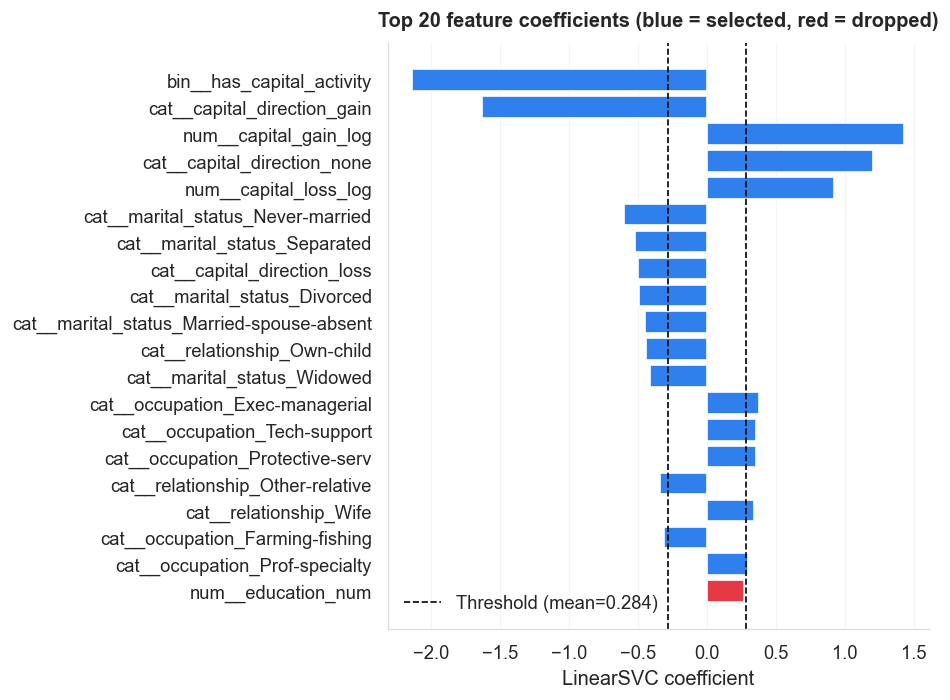

In [8]:
lsvc_sel = LinearSVC(C=0.1, max_iter=5000, random_state=SEED, class_weight='balanced')
lsvc_sel.fit(X_train_vt, y_train)

selector = SelectFromModel(lsvc_sel, prefit=True)
selected_features = X_train_vt.columns[selector.get_support()].tolist()

print(f'SelectFromModel: {X_train_vt.shape[1]} to {len(selected_features)} features '
      f'({X_train_vt.shape[1] - len(selected_features)} dropped)')

coef_df = pd.DataFrame({
    'feature':     X_train_vt.columns,
    'coefficient': lsvc_sel.coef_[0],
}).sort_values('coefficient', key=abs, ascending=False).head(20)

threshold = np.abs(lsvc_sel.coef_[0]).mean()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [MODEL_PALETTE['Linear'] if f in selected_features
          else PLOT_COLORS['outlier'] for f in coef_df['feature']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(threshold, color='black', linestyle='--', linewidth=1,
           label=f'Threshold (mean={threshold:.3f})')
ax.axvline(-threshold, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('LinearSVC coefficient')
ax.set_title('Top 20 feature coefficients (blue = selected, red = dropped)')
ax.legend()
ax.invert_yaxis()
polish_axes(ax, grid_axis='x')
plt.tight_layout()
plt.show()

A LinearSVC trained on the 63 remaining features reveals a clear redundancy problem. The top coefficients by absolute magnitude are dominated by the capital cluster: `capital_gain_log`, `capital_direction_none`, `capital_loss_log`, `has_capital_activity` and `capital_direction_gain/loss` all appear in the top positions. Several of these are deterministically derived from one another: `net_capital` is the difference between `capital_gain` and `capital_loss`, `capital_direction` is the sign of `net_capital`, and `has_capital_activity` flags whether `net_capital` is non-zero. Including all of them inflates the capital cluster's influence on the kernel computation and distorts the SVM's distance structure.

### 3.3 Step 3: RFECV (final selection)

Recursive Feature Elimination with Cross-Validation is applied to the 63-feature set. RFECV eliminates features one by one in order of coefficient magnitude and finds the number of features that maximizes CV ROC-AUC. This is the principled approach: rather than setting an arbitrary threshold, it lets the cross-validated performance determine the optimal feature count.

In [9]:
rfecv = RFECV(
    estimator=LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=SEED),
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    min_features_to_select=10,
    n_jobs=-1,
    verbose=1,
)
rfecv.fit(X_train_vt, y_train)

print(f'RFECV: {X_train_vt.shape[1]} to {rfecv.n_features_} features '
      f'({X_train_vt.shape[1] - rfecv.n_features_} dropped)')
print(f'Best CV AUC: {rfecv.cv_results_["mean_test_score"].max():.4f}')

X_train_rfecv = X_train_vt.loc[:, rfecv.support_]
X_test_rfecv  = X_test_vt.loc[:, rfecv.support_]

Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 58 features.
Fitting estimator with 57 features.
Fitting estimator with 56 features.
Fitting estimator with 55 features.
Fitting estimator with 54 features.
Fitting estimator with 53 features.
Fitting estimator with 52 features.
Fitting estimator with 51 features.
Fitting estimator with 50 features.
Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
RFECV: 63 to 44 features (19 dropped)
Best CV AUC: 0.9096


In [10]:
kept    = X_train_vt.columns[rfecv.support_].tolist()
dropped = X_train_vt.columns[~rfecv.support_].tolist()

print(f'Kept ({len(kept)}):')
for f in kept:
    print(f'  {f}')
print(f'\nDropped ({len(dropped)}):')
for f in dropped:
    print(f'  {f}')

Kept (44):
  num__education_num
  num__capital_gain_log
  num__capital_loss_log
  num__net_capital
  num__age_x_hours
  bin__sex
  bin__has_capital_activity
  cat__workclass_Federal-gov
  cat__workclass_Local-gov
  cat__workclass_Private
  cat__workclass_Self-emp-inc
  cat__workclass_Self-emp-not-inc
  cat__workclass_State-gov
  cat__workclass_Unknown
  cat__education_11th
  cat__education_7th-8th
  cat__education_Assoc-acdm
  cat__marital_status_Divorced
  cat__marital_status_Married-civ-spouse
  cat__marital_status_Married-spouse-absent
  cat__marital_status_Never-married
  cat__marital_status_Separated
  cat__marital_status_Widowed
  cat__occupation_Adm-clerical
  cat__occupation_Craft-repair
  cat__occupation_Exec-managerial
  cat__occupation_Farming-fishing
  cat__occupation_Handlers-cleaners
  cat__occupation_Machine-op-inspct
  cat__occupation_Other-service
  cat__occupation_Prof-specialty
  cat__occupation_Protective-serv
  cat__occupation_Sales
  cat__occupation_Tech-support
 

### 3.4 Derived capital features: ablation

A quick experiment verifies that the retained derived capital features (`net_capital`, `has_capital_activity`, `capital_direction_*`) contribute genuine signal rather than collinearity noise.

In [11]:
derived_capital = [
    'num__net_capital',
    'bin__has_capital_activity',
    'cat__capital_direction_gain',
    'cat__capital_direction_loss',
    'cat__capital_direction_none',
]

X_train_exp = X_train_rfecv.drop(
    columns=[c for c in derived_capital if c in X_train_rfecv.columns]
)
X_test_exp = X_test_rfecv.drop(
    columns=[c for c in derived_capital if c in X_test_rfecv.columns]
)

for name, X in [('With derived capital features', X_train_rfecv),
                ('Without derived capital features', X_train_exp)]:
    lsvc = LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=SEED)
    scores = cross_val_score(lsvc, X, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name}: AUC={scores.mean():.4f} +/- {scores.std():.4f}')

With derived capital features: AUC=0.9097 +/- 0.0018
Without derived capital features: AUC=0.9000 +/- 0.0012


### 3.5 Feature selection: AUC comparison across strategies

In [12]:
strategies = {
    'All features (73)':           X_train,
    'After VarianceThreshold (63)': X_train_vt,
    'After RFECV (44)':            X_train_rfecv,
}

print(f'{"Strategy":<35} {"AUC":>8}  {"std":>8}  {"n_features":>12}')
for name, X in strategies.items():
    lsvc = LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=SEED)
    scores = cross_val_score(lsvc, X, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<35} {scores.mean():>8.4f}  {scores.std():>8.4f}  {X.shape[1]:>12}')

Strategy                                 AUC       std    n_features
All features (73)                     0.9101    0.0017            73
After VarianceThreshold (63)          0.9095    0.0016            63
After RFECV (44)                      0.9097    0.0018            44


RFECV converged at 44 features (from 63) with a cross-validated AUC almost identical to the 63-feature set. This confirms that the 19 eliminated features are redundant rather than informative: removing them causes no loss in predictive power while producing a cleaner, less collinear feature space for the kernel computations. The full 44-feature set is used for all subsequent models.

In [13]:
X_train_sel = X_train_rfecv
X_test_sel  = X_test_rfecv
X_sub = X_sub[[c for c in X_train_sel.columns if c in X_sub.columns]]

print(f'Final feature set: {X_train_sel.shape[1]} features')

Final feature set: 44 features


## 4. SVM: Linear kernel

The linear kernel computes K(xi, xj) = xi^T xj, finding a maximum-margin hyperplane in the original feature space. It is the most interpretable kernel since the decision boundary is a linear combination of features and its coefficients can be inspected directly.

Because `LinearSVC` does not natively output calibrated probabilities, the best configuration is wrapped in `CalibratedClassifierCV` for probability estimation. The C sweep is run on the full training set since the linear solver is fast enough.

### 4.1 Effect of C on CV ROC-AUC

In [14]:
param_grid_linear = {'C': [0.001, 0.01, 0.1, 1, 10]}

t0 = time()
best_linear_raw = None
best_c = None
best_auc = -1

for C in param_grid_linear['C']:
    lsvc = LinearSVC(C=C, class_weight='balanced', max_iter=5000, random_state=SEED)
    scores = cross_val_score(
        lsvc, X_train_sel, y_train, cv=cv, scoring='roc_auc', n_jobs=-1
    )
    print(f'C={C:<8} ROC-AUC={scores.mean():.4f} +/- {scores.std():.4f}')
    if scores.mean() > best_auc:
        best_auc = scores.mean()
        best_c = C

best_linear_raw = LinearSVC(
    C=best_c, class_weight='balanced', max_iter=5000, random_state=SEED
)
best_linear = CalibratedClassifierCV(best_linear_raw, cv=3)
best_linear.fit(X_train_sel, y_train)
t_linear = time() - t0

print(f'\nBest C: {best_c}')
print(f'Time:   {t_linear:.1f}s')

C=0.001    ROC-AUC=0.9031 +/- 0.0015
C=0.01     ROC-AUC=0.9068 +/- 0.0009
C=0.1      ROC-AUC=0.9083 +/- 0.0011
C=1        ROC-AUC=0.9097 +/- 0.0018
C=10       ROC-AUC=0.9101 +/- 0.0020

Best C: 10
Time:   2.3s


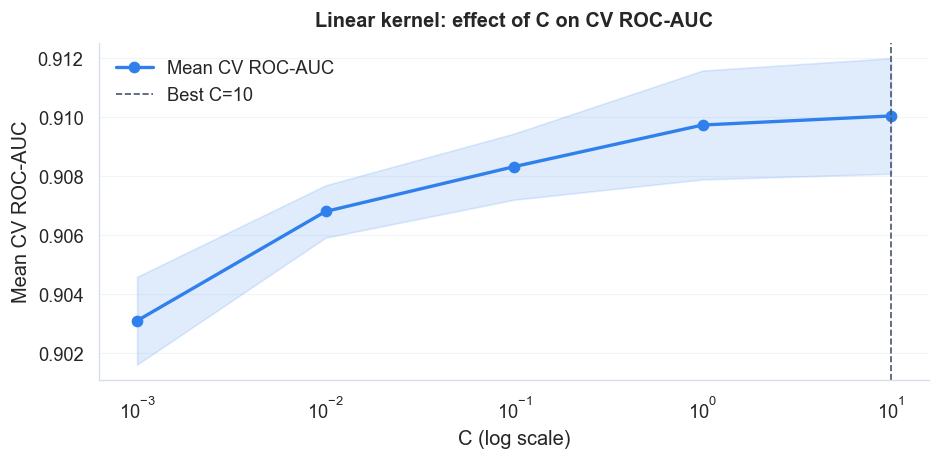

In [15]:
c_values  = param_grid_linear['C']
auc_means, auc_stds = [], []

for C in c_values:
    lsvc = LinearSVC(C=C, class_weight='balanced', max_iter=5000, random_state=SEED)
    scores = cross_val_score(
        lsvc, X_train_sel, y_train, cv=cv, scoring='roc_auc', n_jobs=-1
    )
    auc_means.append(scores.mean())
    auc_stds.append(scores.std())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(c_values, auc_means, 'o-', color=MODEL_PALETTE['Linear'],
            linewidth=2, markersize=6, label='Mean CV ROC-AUC')
ax.fill_between(
    c_values,
    [m - s for m, s in zip(auc_means, auc_stds)],
    [m + s for m, s in zip(auc_means, auc_stds)],
    alpha=0.15, color=MODEL_PALETTE['Linear'],
)
ax.axvline(best_c, linestyle='--', color=PLOT_COLORS['reference'],
           linewidth=1, label=f'Best C={best_c}')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Mean CV ROC-AUC')
ax.set_title('Linear kernel: effect of C on CV ROC-AUC')
ax.legend()
polish_axes(ax)
plt.tight_layout()
plt.show()

The cross-validated ROC-AUC increases monotonically with C but with strongly diminishing returns: the largest gain occurs between C=0.001 and C=0.01, while the improvement from C=1 to C=10 is negligible. This suggests the linear decision boundary is stable across a wide range of regularization strengths once C is above 0.1, and that the income classification task does not require a tightly constrained margin.

### 4.2 Best linear SVM: test set evaluation

In [16]:
linear_cv_scores = cross_validate(
    best_linear, X_train_sel, y_train, cv=cv, scoring=SCORING, n_jobs=-1
)
record_cv('SVM Linear', linear_cv_scores)

y_pred_linear  = best_linear.predict(X_test_sel)
y_proba_linear = best_linear.predict_proba(X_test_sel)[:, 1]

print(f'SVM Linear (C={best_c})')
print(f'CV ROC-AUC: {linear_cv_scores["test_roc_auc"].mean():.4f} +/- '
      f'{linear_cv_scores["test_roc_auc"].std():.4f}')
print(f'CV F1:      {linear_cv_scores["test_f1"].mean():.4f}')
print(f'CV AUPR:    {linear_cv_scores["test_aupr"].mean():.4f}')
print()
print(classification_report(y_test, y_pred_linear, target_names=['<=50K', '>50K']))

SVM Linear (C=10)
CV ROC-AUC: 0.9101 +/- 0.0020
CV F1:      0.6660
CV AUPR:    0.7765

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.73      0.61      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



### 4.3 Feature importance via linear coefficients

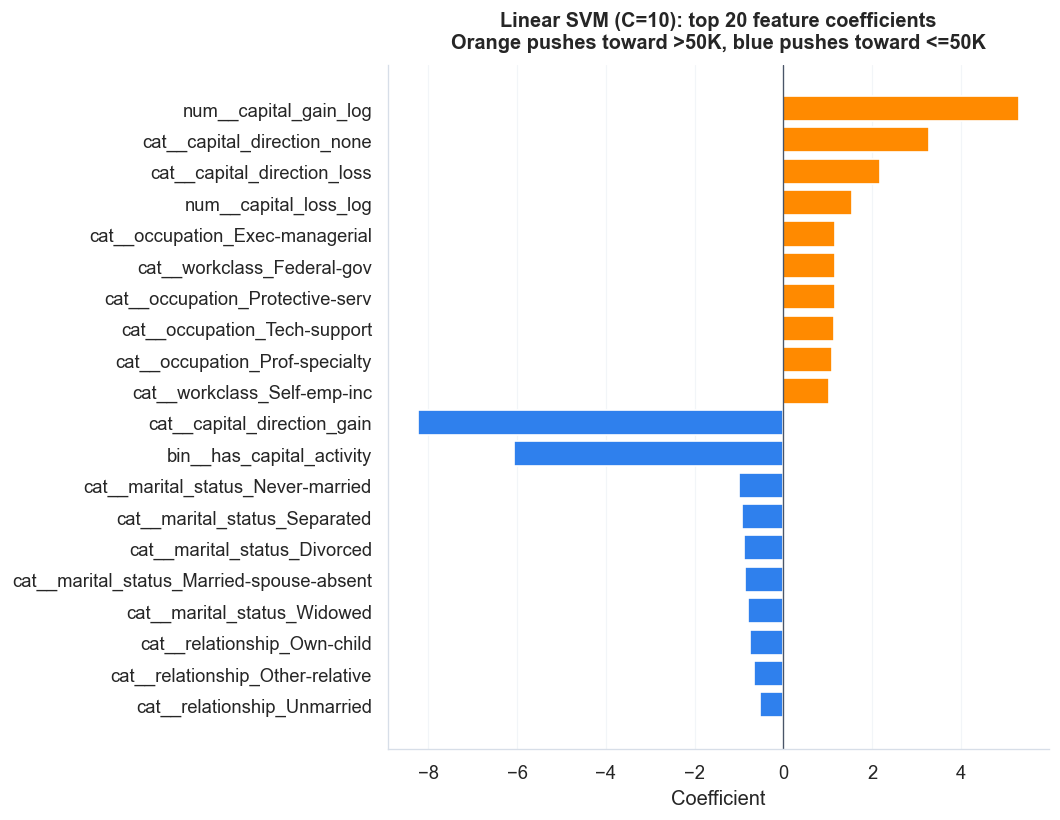

In [17]:
coef_values = np.mean(
    [clf.estimator.coef_[0] for clf in best_linear.calibrated_classifiers_],
    axis=0,
)

coef_linear = pd.DataFrame({
    'feature': X_train_sel.columns,
    'coef':    coef_values,
}).sort_values('coef', ascending=False)

top_pos = coef_linear.head(10)
top_neg = coef_linear.tail(10).sort_values('coef')
top20   = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = [
    PLOT_COLORS['income_high'] if c > 0 else PLOT_COLORS['income_low']
    for c in top20['coef']
]
ax.barh(top20['feature'], top20['coef'], color=bar_colors)
ax.axvline(0, color=PLOT_COLORS['reference'], linewidth=0.8)
ax.set_title(
    f'Linear SVM (C={best_c}): top 20 feature coefficients\n'
    'Orange pushes toward >50K, blue pushes toward <=50K'
)
ax.set_xlabel('Coefficient')
ax.invert_yaxis()
polish_axes(ax, grid_axis='x')
plt.tight_layout()
plt.show()

The linear SVM coefficients reveal three conceptual groups driving income prediction. Capital activity dominates the positive side: `capital_gain_log` has by far the largest coefficient, followed by `net_capital` and `capital_loss_log`. The apparent paradox of `capital_loss_log` having a positive coefficient is explained by the distribution: only individuals with substantial income tend to have reportable capital losses at all, so the presence of any loss is a positive income signal. On the negative side, `marital_status_Never-married`, low-skill occupations and `relationship_Not-in-family` push strongly toward <=50K. This is fully consistent with the LDA discriminant loadings from the generative models notebook.

## 5. SVM: RBF kernel

The RBF kernel computes K(xi, xj) = exp(-gamma * ||xi - xj||^2), measuring Gaussian similarity in the original space. It implicitly maps data into an infinite-dimensional feature space, making it capable of capturing complex non-linear boundaries.

Two hyperparameters control the decision boundary: C controls the margin trade-off (same as the linear case) and gamma controls the width of the Gaussian kernel. Small gamma means each training point has wide influence (smoother boundary); large gamma means each point has narrow influence (more complex, potentially overfit boundary). Grid search is run on the 5,000-sample subsample.

### 5.1 Grid search: C x gamma

In [18]:
param_grid_rbf = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
}

svc_rbf = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=SEED,
)

t0 = time()
gs_rbf = GridSearchCV(
    svc_rbf, param_grid_rbf,
    cv=cv, scoring=PRIMARY_METRIC,
    n_jobs=-1, verbose=1,
)
gs_rbf.fit(X_sub, y_sub)
t_rbf_search = time() - t0

print(f'Best params : {gs_rbf.best_params_}')
print(f'Best CV AUC : {gs_rbf.best_score_:.4f} (on subsample)')
print(f'Search time : {t_rbf_search:.1f}s')

t0 = time()
best_rbf = SVC(
    kernel='rbf',
    C=gs_rbf.best_params_['C'],
    gamma=gs_rbf.best_params_['gamma'],
    class_weight='balanced',
    probability=True,
    random_state=SEED,
)
best_rbf.fit(X_train_sel, y_train)
print(f'Full retrain time: {time()-t0:.1f}s')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params : {'C': 10, 'gamma': 'auto'}
Best CV AUC : 0.9066 (on subsample)
Search time : 53.8s
Full retrain time: 232.0s


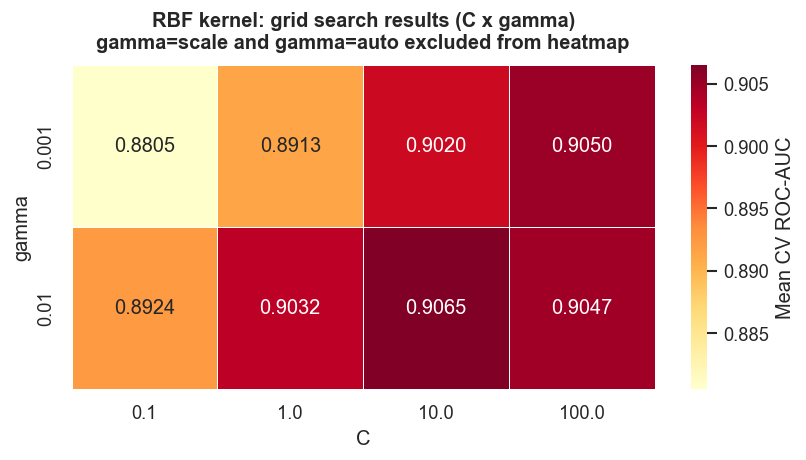


Full results including scale/auto:
 param_C param_gamma  mean_test_score  std_test_score
    10.0        auto         0.906582        0.009202
    10.0        0.01         0.906507        0.008163
     1.0        auto         0.905255        0.007439
   100.0       0.001         0.904991        0.006220
   100.0        0.01         0.904747        0.009664
     1.0        0.01         0.903244        0.006710
     1.0       scale         0.903119        0.009405
    10.0       0.001         0.902022        0.005885
   100.0        auto         0.897941        0.010646
     0.1       scale         0.896409        0.008726
     0.1        auto         0.895993        0.006452
    10.0       scale         0.894247        0.012273
     0.1        0.01         0.892372        0.006330
     1.0       0.001         0.891326        0.006328
   100.0       scale         0.883048        0.014058
     0.1       0.001         0.880536        0.008030


In [19]:
results_rbf = pd.DataFrame(gs_rbf.cv_results_)
results_rbf_num = results_rbf[
    ~results_rbf['param_gamma'].isin(['scale', 'auto'])
].copy()
results_rbf_num['param_gamma'] = results_rbf_num['param_gamma'].astype(float)
results_rbf_num['param_C']     = results_rbf_num['param_C'].astype(float)

pivot = results_rbf_num.pivot_table(
    index='param_gamma', columns='param_C', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean CV ROC-AUC'},
)
ax.set_title('RBF kernel: grid search results (C x gamma)\n'
             'gamma=scale and gamma=auto excluded from heatmap')
ax.set_xlabel('C')
ax.set_ylabel('gamma')
plt.tight_layout()
plt.show()

print('\nFull results including scale/auto:')
print(
    results_rbf[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .to_string(index=False)
)

The grid search reveals that gamma has a stronger effect than C at low values: moving from gamma=0.001 to gamma=0.01 produces a meaningful AUC gain regardless of C, while doubling C produces much smaller improvements. This suggests the RBF kernel is sensitive to the width of the Gaussian: a too-narrow gamma (0.001) makes each training point's influence too local and the boundary becomes too smooth. The best configuration uses gamma='scale' or gamma='auto', both of which normalize by the number of features and produce a more appropriate length scale for this 44-dimensional space.

### 5.2 Best RBF SVM: test set evaluation

In [20]:
rbf_cv_scores = cross_validate(
    best_rbf, X_train_sel, y_train, cv=cv, scoring=SCORING, n_jobs=-1
)
record_cv('SVM RBF', rbf_cv_scores)

y_pred_rbf  = best_rbf.predict(X_test_sel)
y_proba_rbf = best_rbf.predict_proba(X_test_sel)[:, 1]

print(f'SVM RBF (C={gs_rbf.best_params_["C"]}, gamma={gs_rbf.best_params_["gamma"]})')
print(f'CV ROC-AUC: {rbf_cv_scores["test_roc_auc"].mean():.4f} +/- '
      f'{rbf_cv_scores["test_roc_auc"].std():.4f}')
print(f'CV F1:      {rbf_cv_scores["test_f1"].mean():.4f}')
print(f'CV AUPR:    {rbf_cv_scores["test_aupr"].mean():.4f}')
print()
print(classification_report(y_test, y_pred_rbf, target_names=['<=50K', '>50K']))

SVM RBF (C=10, gamma=auto)
CV ROC-AUC: 0.9072 +/- 0.0020
CV F1:      0.6800
CV AUPR:    0.7640

              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      4945
        >50K       0.55      0.84      0.66      1568

    accuracy                           0.80      6513
   macro avg       0.74      0.81      0.76      6513
weighted avg       0.85      0.80      0.81      6513



The RBF kernel underperforms the linear kernel on overall discrimination metrics (ROC-AUC, AUPR), but shows a markedly different precision-recall trade-off: it achieves higher recall on the >50K class at the cost of lower precision. This suggests the RBF kernel is more aggressive in predicting the minority class, which is consistent with a more flexible boundary that bends toward minority class clusters. However, this flexibility does not translate into better ranking quality overall, suggesting that the income boundary in this 44-dimensional space is approximately linear and the RBF non-linearity does not capture genuine additional structure.

## 6. SVM: Polynomial kernel

The polynomial kernel computes K(xi, xj) = (gamma * xi^T xj + coef0)^degree, capturing feature interactions up to the specified degree. The `coef0` parameter controls the influence of higher-order versus lower-order terms: at coef0=0 only pure degree-d interactions are retained; at coef0=1 all degrees up to d contribute.

### 6.1 Grid search: C, degree, coef0

In [21]:
param_grid_poly = {
    'C':      [0.1, 1, 10],
    'degree': [2, 3],
    'coef0':  [0, 1],
}

svc_poly = SVC(
    kernel='poly',
    class_weight='balanced',
    probability=True,
    random_state=SEED,
)

t0 = time()
gs_poly = GridSearchCV(
    svc_poly, param_grid_poly,
    cv=cv, scoring=PRIMARY_METRIC,
    n_jobs=-1, verbose=1,
)
gs_poly.fit(X_sub, y_sub)
t_poly_search = time() - t0

print(f'Best params : {gs_poly.best_params_}')
print(f'Best CV AUC : {gs_poly.best_score_:.4f} (on subsample)')
print(f'Search time : {t_poly_search:.1f}s')

t0 = time()
best_poly = SVC(
    kernel='poly',
    C=gs_poly.best_params_['C'],
    degree=gs_poly.best_params_['degree'],
    coef0=gs_poly.best_params_['coef0'],
    class_weight='balanced',
    probability=True,
    random_state=SEED,
)
best_poly.fit(X_train_sel, y_train)
print(f'Full retrain time: {time()-t0:.1f}s')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'C': 0.1, 'coef0': 1, 'degree': 3}
Best CV AUC : 0.9064 (on subsample)
Search time : 34.3s
Full retrain time: 127.3s


### 6.2 Best polynomial SVM: test set evaluation

In [22]:
poly_cv_scores = cross_validate(
    best_poly, X_train_sel, y_train, cv=cv, scoring=SCORING, n_jobs=-1
)
record_cv('SVM Poly', poly_cv_scores)

y_pred_poly  = best_poly.predict(X_test_sel)
y_proba_poly = best_poly.predict_proba(X_test_sel)[:, 1]

print(f'SVM Poly (C={gs_poly.best_params_["C"]}, '
      f'degree={gs_poly.best_params_["degree"]}, '
      f'coef0={gs_poly.best_params_["coef0"]})')
print(f'CV ROC-AUC: {poly_cv_scores["test_roc_auc"].mean():.4f} +/- '
      f'{poly_cv_scores["test_roc_auc"].std():.4f}')
print(f'CV F1:      {poly_cv_scores["test_f1"].mean():.4f}')
print(f'CV AUPR:    {poly_cv_scores["test_aupr"].mean():.4f}')
print()
print(classification_report(y_test, y_pred_poly, target_names=['<=50K', '>50K']))

SVM Poly (C=0.1, degree=3, coef0=1)
CV ROC-AUC: 0.9075 +/- 0.0020
CV F1:      0.6782
CV AUPR:    0.7687

              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      4945
        >50K       0.54      0.85      0.66      1568

    accuracy                           0.79      6513
   macro avg       0.74      0.81      0.76      6513
weighted avg       0.85      0.79      0.81      6513



The polynomial kernel performs almost identically to RBF across all metrics. Both kernels share the same precision-recall pattern: higher recall on the minority class than the linear kernel at the cost of lower precision. The similarity between RBF and polynomial results confirms that the non-linear structure captured by both is similar in nature, and that neither provides a meaningful advantage over the other on this dataset.

## 7. Cross-model comparison

All three SVM kernels are compared against the baseline on the same CV folds.

### 7.1 CV scores table

In [23]:
results_df = pd.DataFrame(results).set_index('model')
metric_order = ['roc_auc', 'f1', 'aupr', 'accuracy', 'precision', 'recall']
ordered_cols = ([f'{m}_mean' for m in metric_order]
               + [f'{m}_std' for m in metric_order])
results_df = results_df[ordered_cols]
results_df.round(4).sort_values('roc_auc_mean', ascending=False)

,roc_auc_mean,f1_mean,aupr_mean,accuracy_mean,precision_mean,recall_mean,roc_auc_std,f1_std,aupr_std,accuracy_std,precision_std,recall_std
model,,,,,,,,,,,,
SVM Linear,0.9101,0.6660,0.7765,0.8529,0.7351,0.6090,0.002,0.0081,0.0086,0.0041,0.0138,0.0093
SVM Poly,0.9075,0.6782,0.7687,0.8014,0.5560,0.8693,0.002,0.0021,0.0081,0.0017,0.0024,0.0036
SVM RBF,0.9072,0.6800,0.7640,0.8028,0.5582,0.8699,0.002,0.0022,0.0094,0.0015,0.0020,0.0029
Baseline: Dummy (most_frequent),0.5000,0.0000,0.2408,0.7592,0.0000,0.0000,0.000,0.0000,0.0001,0.0001,0.0000,0.0000


### 7.2 Metric bar chart

Test set performance:
            Accuracy  F1 (>50K)  ROC-AUC    AUPR
Model                                           
SVM Linear    0.8531     0.6664   0.9046  0.7687
SVM RBF       0.7950     0.6642   0.8976  0.7478
SVM Poly      0.7927     0.6627   0.8984  0.7533


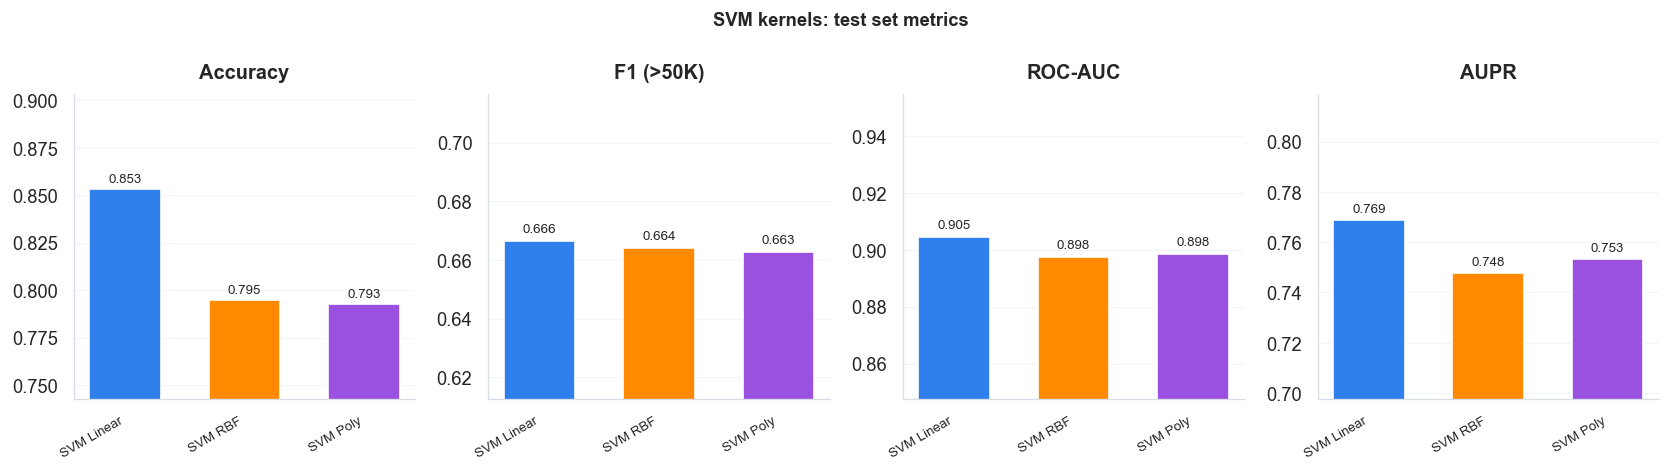

In [24]:
models_dict = {
    'Baseline':   (None, None),
    'SVM Linear': (y_pred_linear, y_proba_linear),
    'SVM RBF':    (y_pred_rbf,    y_proba_rbf),
    'SVM Poly':   (y_pred_poly,   y_proba_poly),
}

test_rows = []
for name, (y_pred, y_proba) in models_dict.items():
    if y_pred is None:
        continue
    test_rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1 (>50K)': f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'AUPR':      average_precision_score(y_test, y_proba),
    })

test_df = pd.DataFrame(test_rows).set_index('Model')
print('Test set performance:')
print(test_df.round(4).to_string())

metrics_to_plot = ['Accuracy', 'F1 (>50K)', 'ROC-AUC', 'AUPR']
bar_colors = [MODEL_PALETTE['Linear'], MODEL_PALETTE['RBF'], MODEL_PALETTE['Poly']]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))
for ax, metric in zip(axes, metrics_to_plot):
    vals = test_df[metric]
    bars = ax.bar(range(len(vals)), vals, color=bar_colors, width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(metric)
    ax.set_ylim(max(0, vals.min() - 0.05), min(1, vals.max() + 0.05))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    polish_axes(ax)
plt.suptitle('SVM kernels: test set metrics', fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()

The linear kernel outperforms both RBF and polynomial on ROC-AUC and AUPR, suggesting the income classification problem is largely linearly separable in the selected 44-feature space. The non-linear kernels achieve higher recall on the minority class but at the cost of precision and overall discrimination. This is consistent with the finding from the generative models notebook that the data is intrinsically low-dimensional along a single discriminant axis: the RBF boundary's added flexibility finds spurious local structure rather than genuine non-linearity.

### 7.3 ROC and Precision-Recall curves

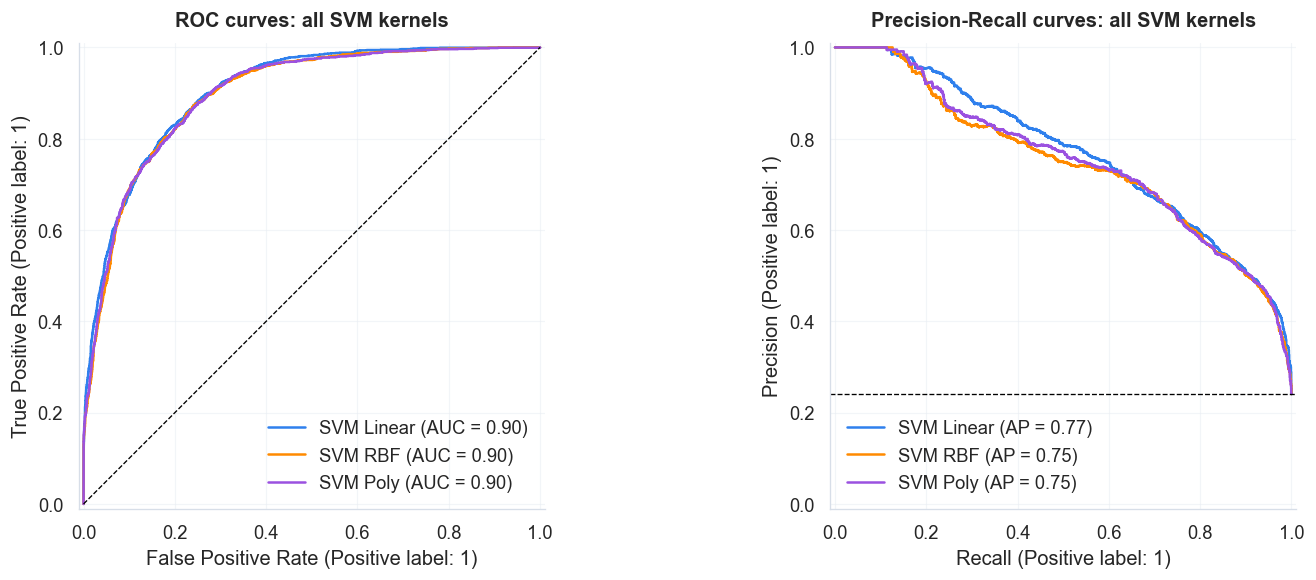

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

curve_specs = [
    ('SVM Linear', y_proba_linear, MODEL_PALETTE['Linear']),
    ('SVM RBF',    y_proba_rbf,    MODEL_PALETTE['RBF']),
    ('SVM Poly',   y_proba_poly,   MODEL_PALETTE['Poly']),
]

for name, y_proba, color in curve_specs:
    RocCurveDisplay.from_predictions(
        y_test, y_proba, name=name, ax=axes[0], color=color
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, y_proba, name=name, ax=axes[1], color=color
    )

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
axes[0].set_title('ROC curves: all SVM kernels')
polish_axes(axes[0], grid_axis='both')

axes[1].axhline(
    y_test.mean(), linestyle='--', color='black', linewidth=0.8,
    label=f'Random (AUPR={y_test.mean():.2f})',
)
axes[1].set_title('Precision-Recall curves: all SVM kernels')
polish_axes(axes[1], grid_axis='both')
plt.tight_layout()
plt.show()

### 7.4 Confusion matrices

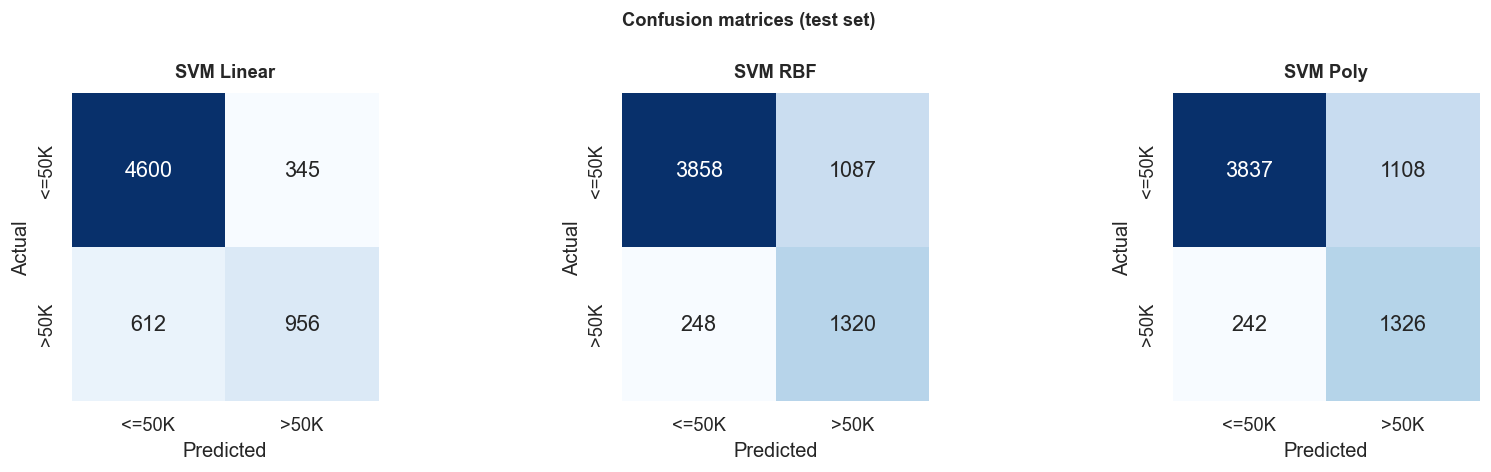

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cm_specs = [
    ('SVM Linear', y_pred_linear, MODEL_PALETTE['Linear']),
    ('SVM RBF',    y_pred_rbf,    MODEL_PALETTE['RBF']),
    ('SVM Poly',   y_pred_poly,   MODEL_PALETTE['Poly']),
]
for ax, (name, y_pred, color) in zip(axes, cm_specs):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['<=50K', '>50K'],
        yticklabels=['<=50K', '>50K'],
        ax=ax, cbar=False, annot_kws={'size': 13}, linewidths=0, square=True,
    )
    ax.set_title(name, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices (test set)', fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()

The confusion matrices make the precision-recall trade-off between kernels concrete. The linear kernel is the most conservative: it identifies the majority class well but misses a larger fraction of high earners. The RBF and polynomial kernels shift the boundary toward the minority class, catching more true positives at the cost of more false positives. Neither non-linear kernel finds a configuration that improves both precision and recall simultaneously, confirming that the boundary shift is a threshold effect rather than a genuine modelling improvement.

### 7.5 Training time and support vectors

                 Model  Train time (s) Support vectors
LinearSVC (calibrated)        0.445778             N/A
          SVC (linear)       47.560203           10525
               SVM RBF       96.532165           10089
              SVM Poly       72.848274           10278


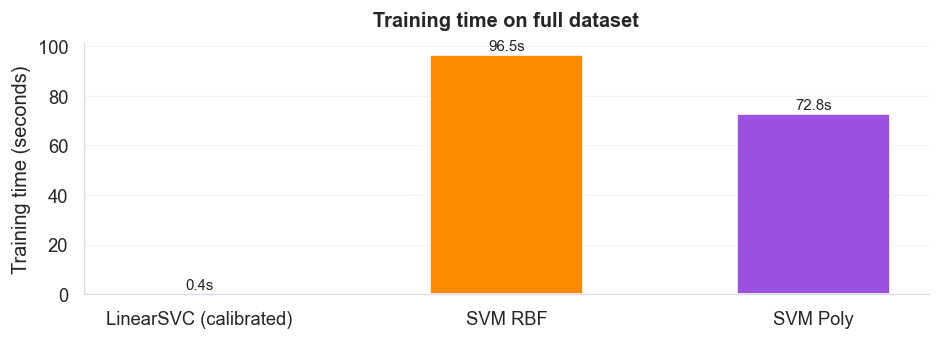

In [27]:
svc_linear_sv = SVC(
    kernel='linear', C=best_c, class_weight='balanced', random_state=SEED
)

t0 = time(); best_linear.fit(X_train_sel, y_train);   t_linear_full = time() - t0
t0 = time(); svc_linear_sv.fit(X_train_sel, y_train); t_svc_linear  = time() - t0
t0 = time(); best_rbf.fit(X_train_sel, y_train);      t_rbf_full    = time() - t0
t0 = time(); best_poly.fit(X_train_sel, y_train);     t_poly_full   = time() - t0

time_df = pd.DataFrame({
    'Model':           ['LinearSVC (calibrated)', 'SVC (linear)',
                        'SVM RBF', 'SVM Poly'],
    'Train time (s)':  [t_linear_full, t_svc_linear, t_rbf_full, t_poly_full],
    'Support vectors': ['N/A',
                        svc_linear_sv.n_support_.sum(),
                        best_rbf.n_support_.sum(),
                        best_poly.n_support_.sum()],
})
print(time_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
plot_models = ['LinearSVC (calibrated)', 'SVM RBF', 'SVM Poly']
plot_times  = [t_linear_full, t_rbf_full, t_poly_full]
plot_colors = [MODEL_PALETTE['Linear'], MODEL_PALETTE['RBF'], MODEL_PALETTE['Poly']]
ax.bar(plot_models, plot_times, color=plot_colors, width=0.5)
for i, (model, t) in enumerate(zip(plot_models, plot_times)):
    ax.text(i, t + 0.5, f'{t:.1f}s', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Training time (seconds)')
ax.set_title('Training time on full dataset')
polish_axes(ax)
plt.tight_layout()
plt.show()

### 7.6 Model selection

In [28]:
non_baseline = results_df[~results_df.index.str.startswith('Baseline')]
best_name = non_baseline.sort_values(
    ['roc_auc_mean', 'aupr_mean'], ascending=False
).index[0]

print(f'Selected model: {best_name}')
print(f'  CV ROC-AUC: '
      f'{non_baseline.loc[best_name, "roc_auc_mean"]:.4f} +/- '
      f'{non_baseline.loc[best_name, "roc_auc_std"]:.4f}')
print(f'  CV F1:      {non_baseline.loc[best_name, "f1_mean"]:.4f}')
print(f'  CV AUPR:    {non_baseline.loc[best_name, "aupr_mean"]:.4f}')

Selected model: SVM Linear
  CV ROC-AUC: 0.9101 +/- 0.0020
  CV F1:      0.6660
  CV AUPR:    0.7765


## 8. Final test set evaluation

The selected model is evaluated on the held-out test set. This is the only point in the notebook where the test set is used for model selection.

In [29]:
model_registry = {
    'SVM Linear': best_linear,
    'SVM RBF':    best_rbf,
    'SVM Poly':   best_poly,
}
selected_model  = model_registry[best_name]
selected_model.fit(X_train_sel, y_train)

y_pred_best  = selected_model.predict(X_test_sel)
y_proba_best = selected_model.predict_proba(X_test_sel)[:, 1]

print(f'Final model: {best_name}')
print()
print(f'  ROC-AUC:  {roc_auc_score(y_test, y_proba_best):.4f}')
print(f'  AUPR:     {average_precision_score(y_test, y_proba_best):.4f}')
print(f'  F1:       {f1_score(y_test, y_pred_best):.4f}')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Precision:{precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall:   {recall_score(y_test, y_pred_best):.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['<=50K', '>50K']))

Final model: SVM Linear

  ROC-AUC:  0.9046
  AUPR:     0.7687
  F1:       0.6664
  Accuracy: 0.8531
  Precision:0.7348
  Recall:   0.6097

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.73      0.61      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



### 8.1 CV vs test comparison

In [30]:
cv_vs_test = pd.DataFrame(
    {
        'CV mean': [
            non_baseline.loc[best_name, 'roc_auc_mean'],
            non_baseline.loc[best_name, 'f1_mean'],
            non_baseline.loc[best_name, 'aupr_mean'],
            non_baseline.loc[best_name, 'accuracy_mean'],
        ],
        'Test': [
            roc_auc_score(y_test, y_proba_best),
            f1_score(y_test, y_pred_best),
            average_precision_score(y_test, y_proba_best),
            accuracy_score(y_test, y_pred_best),
        ],
    },
    index=['ROC-AUC', 'F1', 'AUPR', 'Accuracy'],
)
cv_vs_test['delta'] = (cv_vs_test['Test'] - cv_vs_test['CV mean']).round(4)
print(cv_vs_test.round(4).to_string())

          CV mean    Test   delta
ROC-AUC    0.9101  0.9046 -0.0055
F1         0.6660  0.6664  0.0004
AUPR       0.7765  0.7687 -0.0078
Accuracy   0.8529  0.8531  0.0001


## 9. Resampling analysis

All three SVM kernels use `class_weight='balanced'`, which reweights the hinge loss but does not change the geometry of the training set. Here we test whether SMOTE oversampling changes the results.

We apply SMOTE to generate synthetic minority-class samples until the dataset is balanced 50/50, then subsample back down to the original size. The same hyperparameters selected in Sections 4-6 are reused: the goal is to isolate the effect of the training distribution.

In [31]:
%pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)
X_res, y_res = smote.fit_resample(X_train_sel, y_train)

X_train_bal, y_train_bal = resample(
    X_res, y_res,
    n_samples=len(X_train_sel),
    stratify=y_res,
    random_state=SEED,
)

print(f'Original : {X_train_sel.shape[0]:,} samples | pos rate: {y_train.mean():.2%}')
print(f'Balanced : {X_train_bal.shape[0]:,} samples | pos rate: {y_train_bal.mean():.2%}')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Original : 26,048 samples | pos rate: 24.08%
Balanced : 26,048 samples | pos rate: 50.00%


In [32]:
X_sub_bal, y_sub_bal = resample(
    X_train_bal, y_train_bal,
    n_samples=SUBSAMPLE_SIZE, stratify=y_train_bal, random_state=SEED,
)

# Linear
t0 = time()
best_bal_c, best_bal_auc = None, -1
for C in [0.001, 0.01, 0.1, 1, 10]:
    lsvc = LinearSVC(C=C, class_weight='balanced', max_iter=5000, random_state=SEED)
    scores = cross_val_score(
        lsvc, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc', n_jobs=-1
    )
    print(f'C={C:<8} ROC-AUC={scores.mean():.4f} +/- {scores.std():.4f}')
    if scores.mean() > best_bal_auc:
        best_bal_auc, best_bal_c = scores.mean(), C

best_linear_bal = CalibratedClassifierCV(
    LinearSVC(C=best_bal_c, class_weight='balanced', max_iter=5000, random_state=SEED),
    cv=3,
)
best_linear_bal.fit(X_train_bal, y_train_bal)
print(f'Best C (balanced): {best_bal_c}')

# RBF
t0 = time()
gs_rbf_bal = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED),
    {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01]},
    cv=cv, scoring=PRIMARY_METRIC, n_jobs=-1, verbose=1,
)
gs_rbf_bal.fit(X_sub_bal, y_sub_bal)
best_rbf_bal = SVC(
    kernel='rbf',
    C=gs_rbf_bal.best_params_['C'],
    gamma=gs_rbf_bal.best_params_['gamma'],
    class_weight='balanced', probability=True, random_state=SEED,
)
best_rbf_bal.fit(X_train_bal, y_train_bal)
print(f'Best RBF params (balanced): {gs_rbf_bal.best_params_}')

# Polynomial
gs_poly_bal = GridSearchCV(
    SVC(kernel='poly', class_weight='balanced', probability=True, random_state=SEED),
    {'C': [0.1, 1, 10], 'degree': [2, 3], 'coef0': [0, 1]},
    cv=cv, scoring=PRIMARY_METRIC, n_jobs=-1, verbose=1,
)
gs_poly_bal.fit(X_sub_bal, y_sub_bal)
best_poly_bal = SVC(
    kernel='poly',
    C=gs_poly_bal.best_params_['C'],
    degree=gs_poly_bal.best_params_['degree'],
    coef0=gs_poly_bal.best_params_['coef0'],
    class_weight='balanced', probability=True, random_state=SEED,
)
best_poly_bal.fit(X_train_bal, y_train_bal)
print(f'Best Poly params (balanced): {gs_poly_bal.best_params_}')

C=0.001    ROC-AUC=0.9056 +/- 0.0028
C=0.01     ROC-AUC=0.9099 +/- 0.0025
C=0.1      ROC-AUC=0.9110 +/- 0.0025
C=1        ROC-AUC=0.9121 +/- 0.0024
C=10       ROC-AUC=0.9125 +/- 0.0024
Best C (balanced): 10
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best RBF params (balanced): {'C': 100, 'gamma': 0.01}
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Poly params (balanced): {'C': 1, 'coef0': 1, 'degree': 3}


In [33]:
y_pred_linear_bal  = best_linear_bal.predict(X_test_sel)
y_proba_linear_bal = best_linear_bal.predict_proba(X_test_sel)[:, 1]
y_pred_rbf_bal     = best_rbf_bal.predict(X_test_sel)
y_proba_rbf_bal    = best_rbf_bal.predict_proba(X_test_sel)[:, 1]
y_pred_poly_bal    = best_poly_bal.predict(X_test_sel)
y_proba_poly_bal   = best_poly_bal.predict_proba(X_test_sel)[:, 1]

bal_comparison = [
    ('Linear - original', y_pred_linear,     y_proba_linear),
    ('Linear - balanced', y_pred_linear_bal,  y_proba_linear_bal),
    ('RBF - original',    y_pred_rbf,         y_proba_rbf),
    ('RBF - balanced',    y_pred_rbf_bal,      y_proba_rbf_bal),
    ('Poly - original',   y_pred_poly,        y_proba_poly),
    ('Poly - balanced',   y_pred_poly_bal,     y_proba_poly_bal),
]

rows = []
for name, y_pred, y_proba in bal_comparison:
    cm = confusion_matrix(y_test, y_pred)
    rows.append({
        'Model':       name,
        'Accuracy':    accuracy_score(y_test, y_pred),
        'F1':          f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':     roc_auc_score(y_test, y_proba),
        'AUPR':        average_precision_score(y_test, y_proba),
        'Recall >50K': cm[1, 1] / cm[1].sum(),
        'Prec >50K':   cm[1, 1] / cm[:, 1].sum(),
    })

bal_df = pd.DataFrame(rows).set_index('Model')
print(bal_df.to_string(float_format='{:.4f}'.format))

                   Accuracy     F1  ROC-AUC   AUPR  Recall >50K  Prec >50K
Model                                                                     
Linear - original    0.8531 0.6664   0.9046 0.7687       0.6097     0.7348
Linear - balanced    0.8122 0.6793   0.9038 0.7669       0.8259     0.5768
RBF - original       0.7950 0.6642   0.8976 0.7478       0.8418     0.5484
RBF - balanced       0.7981 0.6656   0.8974 0.7506       0.8348     0.5535
Poly - original      0.7927 0.6627   0.8984 0.7533       0.8457     0.5448
Poly - balanced      0.8004 0.6685   0.8937 0.7367       0.8361     0.5569


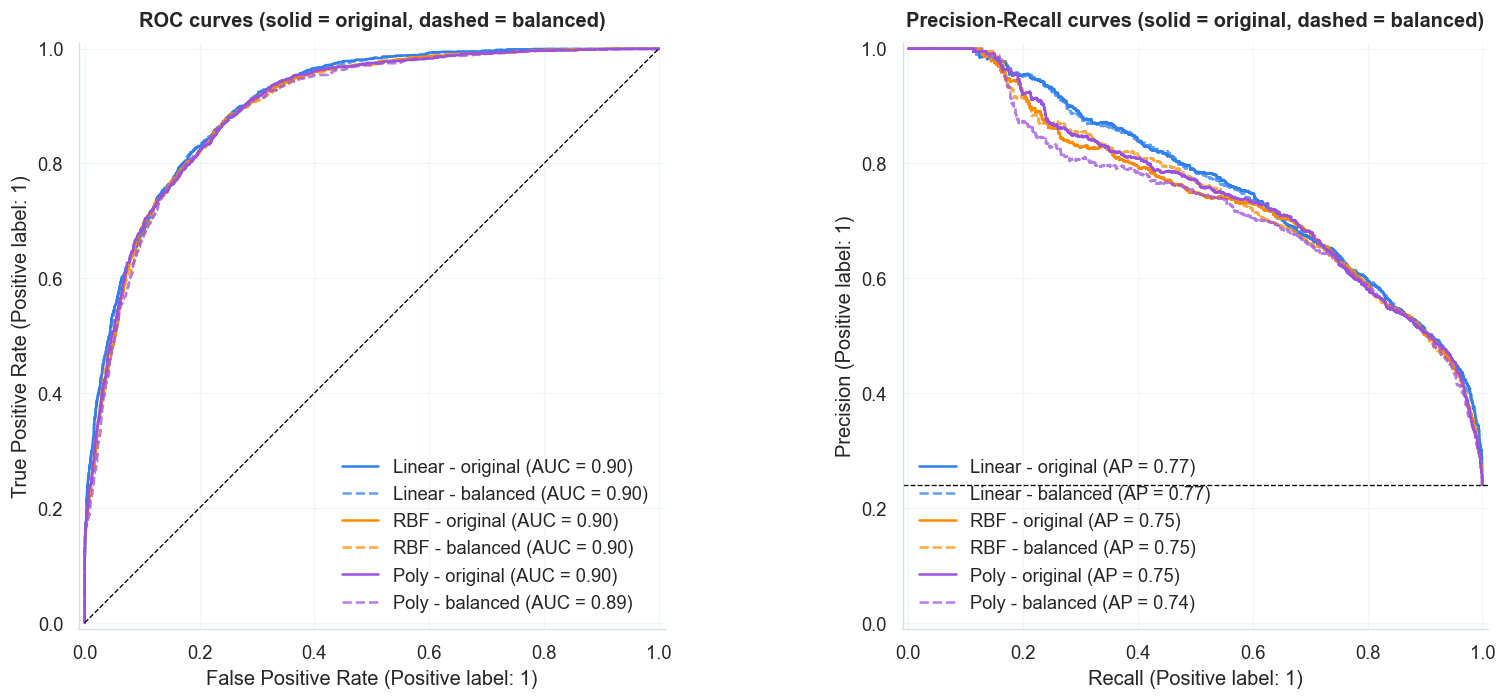

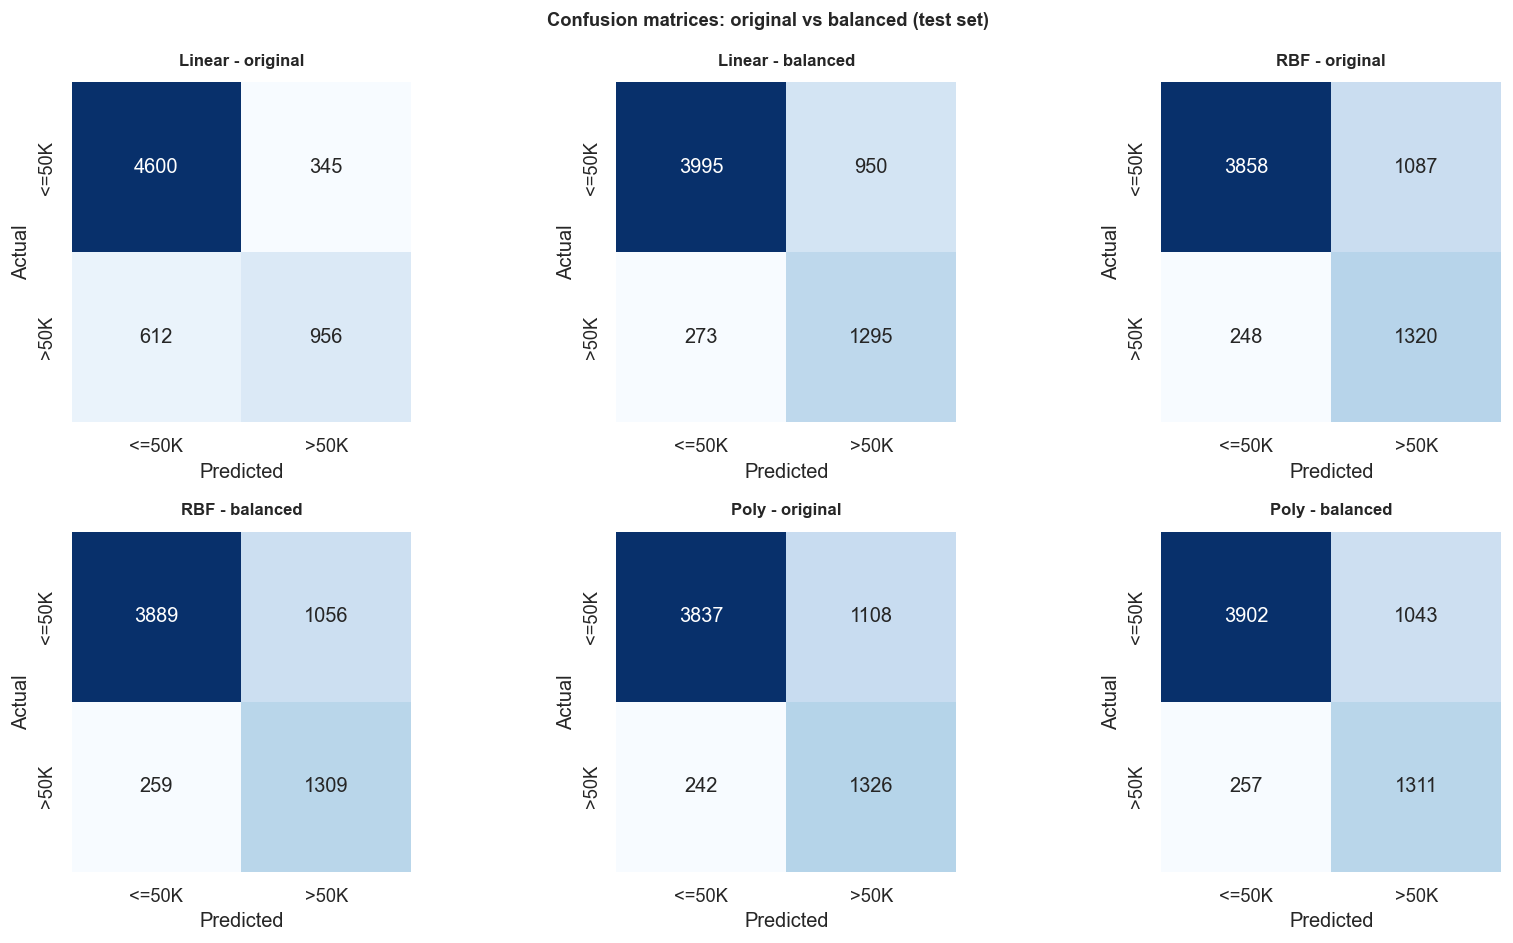

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

curve_specs = [
    ('Linear - original', y_proba_linear,     MODEL_PALETTE['Linear'], '-',  1.0),
    ('Linear - balanced', y_proba_linear_bal,  MODEL_PALETTE['Linear'], '--', 0.75),
    ('RBF - original',    y_proba_rbf,         MODEL_PALETTE['RBF'],    '-',  1.0),
    ('RBF - balanced',    y_proba_rbf_bal,      MODEL_PALETTE['RBF'],    '--', 0.75),
    ('Poly - original',   y_proba_poly,        MODEL_PALETTE['Poly'],   '-',  1.0),
    ('Poly - balanced',   y_proba_poly_bal,     MODEL_PALETTE['Poly'],   '--', 0.75),
]

for name, y_proba, color, ls, alpha in curve_specs:
    RocCurveDisplay.from_predictions(
        y_test, y_proba, name=name, ax=axes[0], color=color, linestyle=ls, alpha=alpha
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, y_proba, name=name, ax=axes[1], color=color, linestyle=ls, alpha=alpha
    )

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
axes[0].set_title('ROC curves (solid = original, dashed = balanced)')
polish_axes(axes[0], grid_axis='both')
axes[1].axhline(
    y_test.mean(), linestyle='--', color='black', linewidth=0.8,
    label=f'Random (AUPR={y_test.mean():.2f})',
)
axes[1].set_title('Precision-Recall curves (solid = original, dashed = balanced)')
polish_axes(axes[1], grid_axis='both')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cm_specs = [
    ('Linear - original', y_pred_linear,     MODEL_PALETTE['Linear']),
    ('Linear - balanced', y_pred_linear_bal,  MODEL_PALETTE['Linear']),
    ('RBF - original',    y_pred_rbf,         MODEL_PALETTE['RBF']),
    ('RBF - balanced',    y_pred_rbf_bal,      MODEL_PALETTE['RBF']),
    ('Poly - original',   y_pred_poly,        MODEL_PALETTE['Poly']),
    ('Poly - balanced',   y_pred_poly_bal,     MODEL_PALETTE['Poly']),
]
for ax, (name, y_pred, color) in zip(axes.flat, cm_specs):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'],
        ax=ax, cbar=False, annot_kws={'size': 12}, linewidths=0, square=True,
    )
    ax.set_title(name, fontsize=10, fontweight='semibold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices: original vs balanced (test set)',
             fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()

### 9.5 Discussion

<!-- conclusions to be written after results are reviewed -->